In [16]:
# 3. Imports & Config
import os, json, time, math, warnings
from dataclasses import dataclass
from typing import Tuple, Dict, Any, List, Optional

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score, learning_curve
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve, auc
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import calibration_curve
from sklearn.base import BaseEstimator

import joblib

warnings.filterwarnings("ignore")

@dataclass
class Config:
    dataset_path: str = "./UCI_Credit_Card.csv"  # change if needed
    target_candidates: Tuple[str, ...] = ("default.payment.next.month", "default", "DEFAULT", "y")
    id_cols: Tuple[str, ...] = ("ID",)
    test_size: float = 0.2
    val_size: float = 0.1
    random_state: int = 42
    n_splits_cv: int = 5
    n_iter_search: int = 35
    scoring: str = "roc_auc"
    top_n_features_plot: int = 20
    models_dir: str = "./models"
    outputs_dir: str = "./outputs"
    style: str = "whitegrid"

CFG = Config()

sns.set_style(CFG.style)
os.makedirs(CFG.models_dir, exist_ok=True)
os.makedirs(CFG.outputs_dir, exist_ok=True)

print("Config loaded.")

Config loaded.


In [ ]:
# 4. Data Path Setup (Edit if necessary)


DATASET_PATH = CFG.dataset_path
print("DATASET_PATH:", DATASET_PATH)

DATASET_PATH: ./UCI_Credit_Card.csv


In [18]:
# 5. Helper Functions
from pathlib import Path

def try_infer_dataset_path(path: str) -> str:
    if os.path.exists(path):
        return path
    kaggle_paths = [
        "/kaggle/input/uci-credit-card/UCI_Credit_Card.csv",
        "/kaggle/input/credit-card-default-prediction/UCI_Credit_Card.csv",
    ]
    for p in kaggle_paths:
        if os.path.exists(p):
            return p
    win_example = r"d:\\C_Drive_Moved\\Downloads\\UCI_Credit_Card.csv\\UCI_Credit_Card.csv"
    if os.path.exists(win_example):
        return win_example
    return path


def detect_target(df: pd.DataFrame) -> str:
    for c in CFG.target_candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Target column not found. Expected one of {CFG.target_candidates}")


def compute_balanced_sample_weights(y: pd.Series) -> np.ndarray:
    classes = np.unique(y)
    class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    class_weight_map = {c: w for c, w in zip(classes, class_weights)}
    return y.map(class_weight_map).astype(float).to_numpy()


def make_ohe() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_pipeline(numeric_cols: List[str], categorical_cols: List[str]) -> Pipeline:
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_ohe())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    gbm = GradientBoostingClassifier(random_state=CFG.random_state)

    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", gbm)
    ])
    return pipe


def get_param_distributions() -> Dict[str, Any]:
    return {
        "model__n_estimators": np.arange(100, 601, 25),
        "model__learning_rate": np.linspace(0.01, 0.2, 20),
        "model__max_depth": [2, 3, 4, 5],
        "model__subsample": np.linspace(0.6, 1.0, 9),
        "model__min_samples_split": [2, 5, 10, 20, 50, 100],
        "model__min_samples_leaf": [1, 2, 5, 10, 20, 50],
        "model__max_features": [None, "sqrt", "log2"],
    }


def evaluate_all(y_true: np.ndarray, y_pred: np.ndarray, y_proba: Optional[np.ndarray]) -> Dict[str, float]:
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        try:
            results["roc_auc"] = roc_auc_score(y_true, y_proba)
        except Exception:
            results["roc_auc"] = float("nan")
    return results

In [19]:
# 6. Load Data
resolved_path = try_infer_dataset_path(DATASET_PATH)
print("Resolved dataset path:", resolved_path)
assert os.path.exists(resolved_path), f"CSV not found at {resolved_path}. Upload it or set DATASET_PATH."

df = pd.read_csv(resolved_path)
print("Data shape:", df.shape)

target_col = None
try:
    target_col = detect_target(df)
except Exception as e:
    print("Error detecting target:", e)
    raise
print("Target column:", target_col)

df.head()

Resolved dataset path: ./UCI_Credit_Card.csv
Data shape: (30000, 25)
Target column: default.payment.next.month


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
# 7. Preprocess and Split



# Drop IDs if present
id_drop = [c for c in CFG.id_cols if c in df.columns]
if id_drop:
    df = df.drop(columns=id_drop)

# Split features/target
X = df.drop(columns=[target_col])
y = df[target_col]

# Identify types
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")
print(f"Positive rate: {y.mean():.3f}")

# Split to train/val/test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=CFG.test_size, stratify=y, random_state=CFG.random_state
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=CFG.val_size, stratify=y_train_val, random_state=CFG.random_state
)

len(X_train), len(X_val), len(X_test)

Numeric cols: 23, Categorical cols: 0
Positive rate: 0.221


(21600, 2400, 6000)

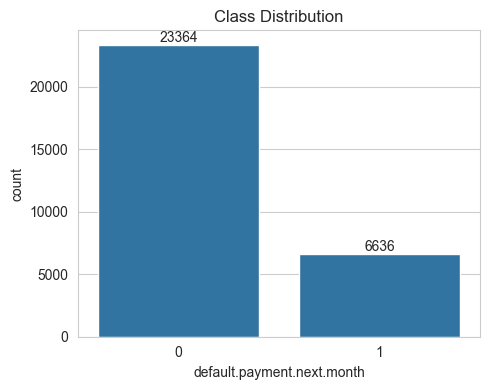

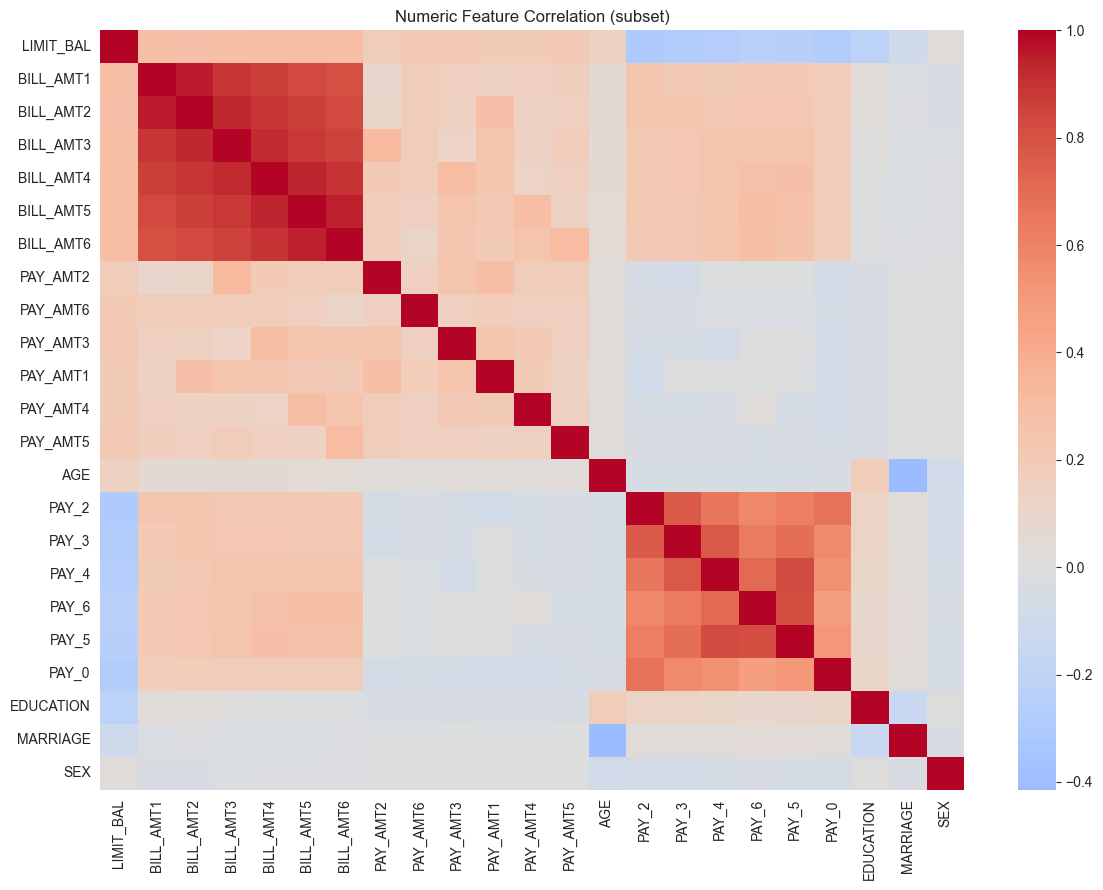

In [ ]:
# 8. Visualizations
sns.set_style(CFG.style)

# Class distribution
plt.figure(figsize=(5,4))
ax = sns.countplot(x=y)
plt.title("Class Distribution")
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f"{count}", (p.get_x()+p.get_width()/2, count), ha="center", va="bottom")
plt.tight_layout()
plt.savefig(os.path.join(CFG.outputs_dir, "class_distribution.png"), bbox_inches="tight")
plt.show()

# Correlation heatmap on numeric subset
num_df = X.select_dtypes(include=[np.number])
sel_cols = num_df.var().sort_values(ascending=False).head(25).index.tolist()
plt.figure(figsize=(12,9))
sns.heatmap(num_df[sel_cols].corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation (subset)")
plt.tight_layout()
plt.savefig(os.path.join(CFG.outputs_dir, "corr_heatmap.png"), bbox_inches="tight")
plt.show()

In [22]:
# 9. Baseline Model
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
y_val_pred_bl = baseline.predict(X_val)

baseline_metrics = {
    "accuracy": accuracy_score(y_val, y_val_pred_bl),
    "balanced_accuracy": balanced_accuracy_score(y_val, y_val_pred_bl),
    "precision": precision_score(y_val, y_val_pred_bl, zero_division=0),
    "recall": recall_score(y_val, y_val_pred_bl, zero_division=0),
    "f1": f1_score(y_val, y_val_pred_bl, zero_division=0)
}
print(json.dumps(baseline_metrics, indent=2))

{
  "accuracy": 0.77875,
  "balanced_accuracy": 0.5,
  "precision": 0.0,
  "recall": 0.0,
  "f1": 0.0
}


In [ ]:
# 10. Pipeline, CV, and Randomized Search
pipe = build_pipeline(num_cols, cat_cols)
param_dist = get_param_distributions()
skf = StratifiedKFold(n_splits=CFG.n_splits_cv, shuffle=True, random_state=CFG.random_state)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=CFG.n_iter_search,
    scoring=CFG.scoring,
    n_jobs=-1,
    cv=skf,
    verbose=1,
    random_state=CFG.random_state,
    refit=True
)

search.fit(X_train_val, y_train_val, model__sample_weight=compute_balanced_sample_weights(y_train_val))
print("Best CV score (ROC-AUC):", search.best_score_)
print("Best params:", search.best_params_)

Fitting 5 folds for each of 35 candidates, totalling 175 fits


In [ ]:
# 11. Validation and Test Evaluation
final_model = search.best_estimator_

# Validation quick check
y_val_proba = final_model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_proba >= 0.5).astype(int)
val_metrics = {
    "accuracy": accuracy_score(y_val, y_val_pred),
    "balanced_accuracy": balanced_accuracy_score(y_val, y_val_pred),
    "precision": precision_score(y_val, y_val_pred, zero_division=0),
    "recall": recall_score(y_val, y_val_pred, zero_division=0),
    "f1": f1_score(y_val, y_val_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_val, y_val_proba),
}
print("Validation:")
print(json.dumps(val_metrics, indent=2))

# Test evaluation
y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

test_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
    "precision": precision_score(y_test, y_test_pred, zero_division=0),
    "recall": recall_score(y_test, y_test_pred, zero_division=0),
    "f1": f1_score(y_test, y_test_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_test_proba),
}
print("Test:")
print(json.dumps(test_metrics, indent=2))

print("\nClassification report (Test):\n", classification_report(y_test, y_test_pred, digits=4))

Validation:
{
  "accuracy": 0.7691666666666667,
  "balanced_accuracy": 0.7230399047195848,
  "precision": 0.48364153627311524,
  "recall": 0.64030131826742,
  "f1": 0.5510534846029174,
  "roc_auc": 0.8197702831105993
}
Test:
{
  "accuracy": 0.7658333333333334,
  "balanced_accuracy": 0.7150420467690178,
  "precision": 0.47750865051903113,
  "recall": 0.6239638281838734,
  "f1": 0.540999673309376,
  "roc_auc": 0.7803602797000712
}

Classification report (Test):
               precision    recall  f1-score   support

           0     0.8830    0.8061    0.8428      4673
           1     0.4775    0.6240    0.5410      1327

    accuracy                         0.7658      6000
   macro avg     0.6803    0.7150    0.6919      6000
weighted avg     0.7933    0.7658    0.7761      6000



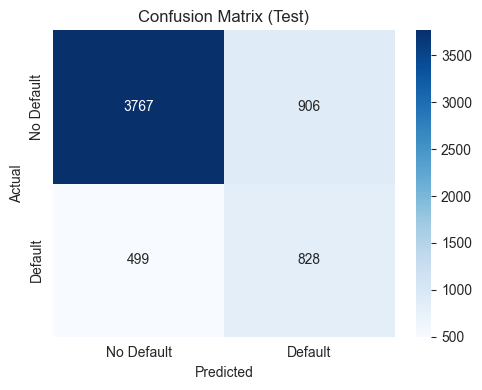

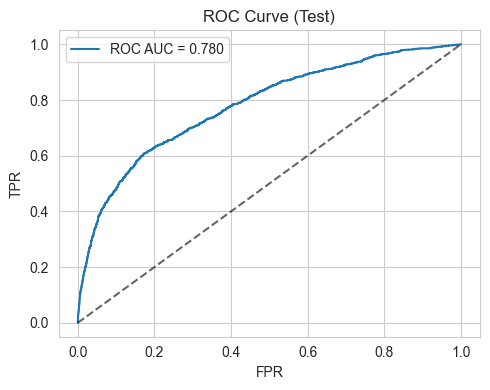

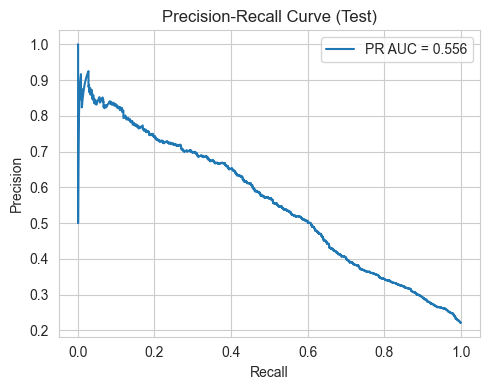

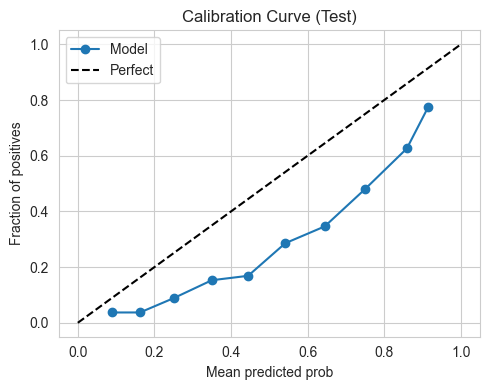

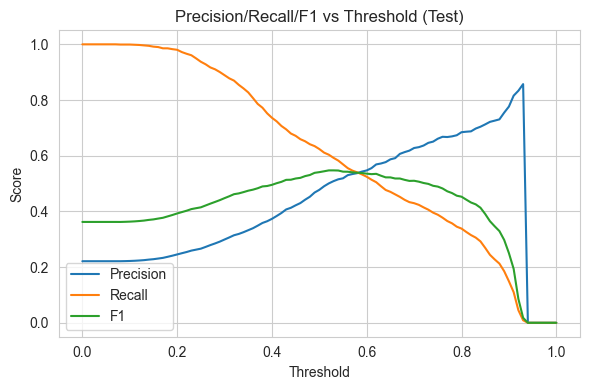

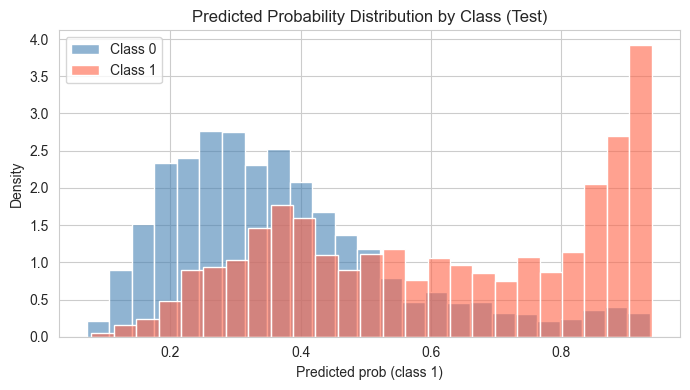

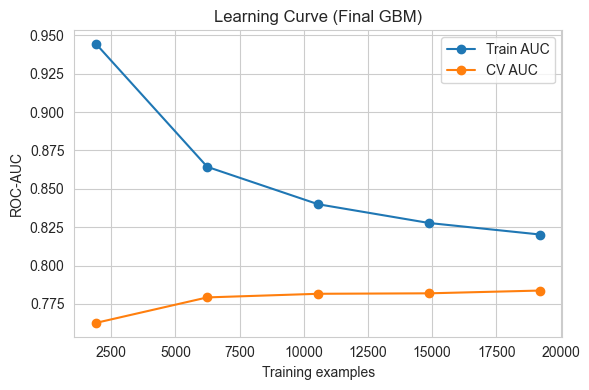

In [ ]:
# 12. Visualizations
from sklearn.metrics import roc_curve, precision_recall_curve

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Default","Default"], yticklabels=["No Default","Default"])
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(CFG.outputs_dir, "confusion_matrix.png"), bbox_inches="tight")
plt.show()

# ROC & PR
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--", alpha=0.6)
plt.title("ROC Curve (Test)")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CFG.outputs_dir, "gbm_roc.png"), bbox_inches="tight")
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
pr_auc = auc(recall, precision)
plt.figure(figsize=(5,4))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.title("Precision-Recall Curve (Test)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CFG.outputs_dir, "gbm_pr.png"), bbox_inches="tight")
plt.show()

# Calibration curve
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=10, strategy="uniform")
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0,1],[0,1],"k--", label="Perfect")
plt.title("Calibration Curve (Test)")
plt.xlabel("Mean predicted prob")
plt.ylabel("Fraction of positives")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CFG.outputs_dir, "calibration_curve.png"), bbox_inches="tight")
plt.show()

# Threshold curves
thresholds = np.linspace(0,1,101)
precs, recs, f1s = [], [], []
for t in thresholds:
    yp = (y_test_proba >= t).astype(int)
    precs.append(precision_score(y_test, yp, zero_division=0))
    recs.append(recall_score(y_test, yp, zero_division=0))
    f1s.append(f1_score(y_test, yp, zero_division=0))
plt.figure(figsize=(6,4))
plt.plot(thresholds, precs, label="Precision")
plt.plot(thresholds, recs, label="Recall")
plt.plot(thresholds, f1s, label="F1")
plt.title("Precision/Recall/F1 vs Threshold (Test)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CFG.outputs_dir, "threshold_curves.png"), bbox_inches="tight")
plt.show()

# Probability histograms
prob_df = pd.DataFrame({"y_true": y_test.to_numpy(), "proba": y_test_proba})
plt.figure(figsize=(7,4))
sns.histplot(data=prob_df[prob_df["y_true"]==0], x="proba", color="steelblue", bins=25, stat="density", alpha=0.6, label="Class 0")
sns.histplot(data=prob_df[prob_df["y_true"]==1], x="proba", color="tomato", bins=25, stat="density", alpha=0.6, label="Class 1")
plt.title("Predicted Probability Distribution by Class (Test)")
plt.xlabel("Predicted prob (class 1)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CFG.outputs_dir, "probability_hist_by_class.png"), bbox_inches="tight")
plt.show()





# Learning curve (final model)
train_sizes, train_scores, val_scores = learning_curve(
    final_model, X_train_val, y_train_val, cv=skf, scoring="roc_auc",
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5), shuffle=True, random_state=CFG.random_state
)
plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train AUC')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='CV AUC')
plt.title("Learning Curve (Final GBM)")
plt.xlabel("Training examples")
plt.ylabel("ROC-AUC")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CFG.outputs_dir, "learning_curve_final.png"), bbox_inches="tight")
plt.show()

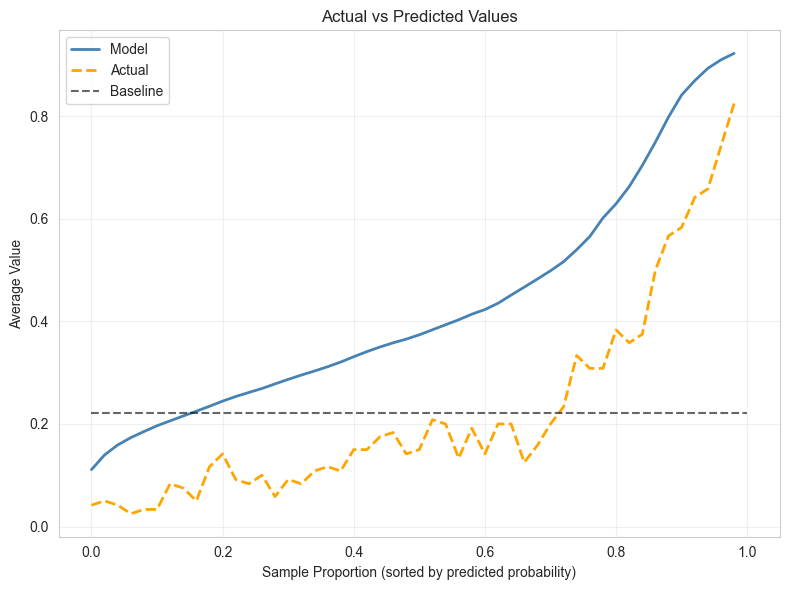

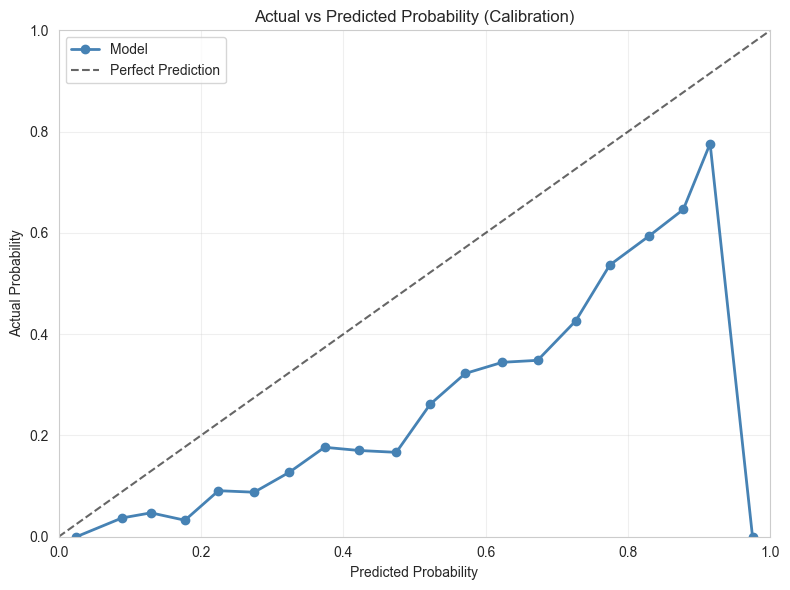

In [ ]:
# Actual vs Predicted Line Chart (similar to ROC style)
plt.figure(figsize=(8, 6))

# Sort the data by predicted probabilities for a smooth line
sort_idx = np.argsort(y_test_proba)
sorted_actual = y_test.to_numpy()[sort_idx]
sorted_predicted_proba = y_test_proba[sort_idx]

# Create cumulative averages for smoothing
window_size = len(y_test) // 50  # Use 50 points for smooth lines
actual_smooth = []
predicted_smooth = []
x_points = []

for i in range(0, len(y_test), window_size):
    end_idx = min(i + window_size, len(y_test))
    actual_smooth.append(np.mean(sorted_actual[i:end_idx]))
    predicted_smooth.append(np.mean(sorted_predicted_proba[i:end_idx]))
    x_points.append(i / len(y_test))

# Plot the lines
plt.plot(x_points, predicted_smooth, label='Model', linewidth=2, color='steelblue')
plt.plot(x_points, actual_smooth, label='Actual', linewidth=2, color='orange', linestyle='--')

# Add baseline (random classifier)
plt.plot([0, 1], [y_test.mean(), y_test.mean()], 'k--', alpha=0.6, label='Baseline')

plt.xlabel('Sample Proportion (sorted by predicted probability)')
plt.ylabel('Average Value')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CFG.outputs_dir, "actual_vs_predicted_line.png"), bbox_inches="tight", dpi=150)
plt.show()

# Alternative: Actual vs Predicted with perfect prediction line
plt.figure(figsize=(8, 6))

# Create bins for actual vs predicted comparison
n_bins = 20
bin_boundaries = np.linspace(0, 1, n_bins + 1)
bin_centers = (bin_boundaries[:-1] + bin_boundaries[1:]) / 2

actual_binned = []
predicted_binned = []

for i in range(n_bins):
    mask = (y_test_proba >= bin_boundaries[i]) & (y_test_proba < bin_boundaries[i + 1])
    if i == n_bins - 1:  # Include the last boundary
        mask = (y_test_proba >= bin_boundaries[i]) & (y_test_proba <= bin_boundaries[i + 1])
    
    if np.sum(mask) > 0:
        actual_binned.append(np.mean(y_test.to_numpy()[mask]))
        predicted_binned.append(np.mean(y_test_proba[mask]))
    else:
        actual_binned.append(0)
        predicted_binned.append(bin_centers[i])

# Plot
plt.plot(predicted_binned, actual_binned, 'o-', label='Model', linewidth=2, markersize=6, color='steelblue')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Perfect Prediction')

plt.xlabel('Predicted Probability')
plt.ylabel('Actual Probability')
plt.title('Actual vs Predicted Probability (Calibration)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(CFG.outputs_dir, "actual_vs_predicted_calibration.png"), bbox_inches="tight", dpi=150)
plt.show()

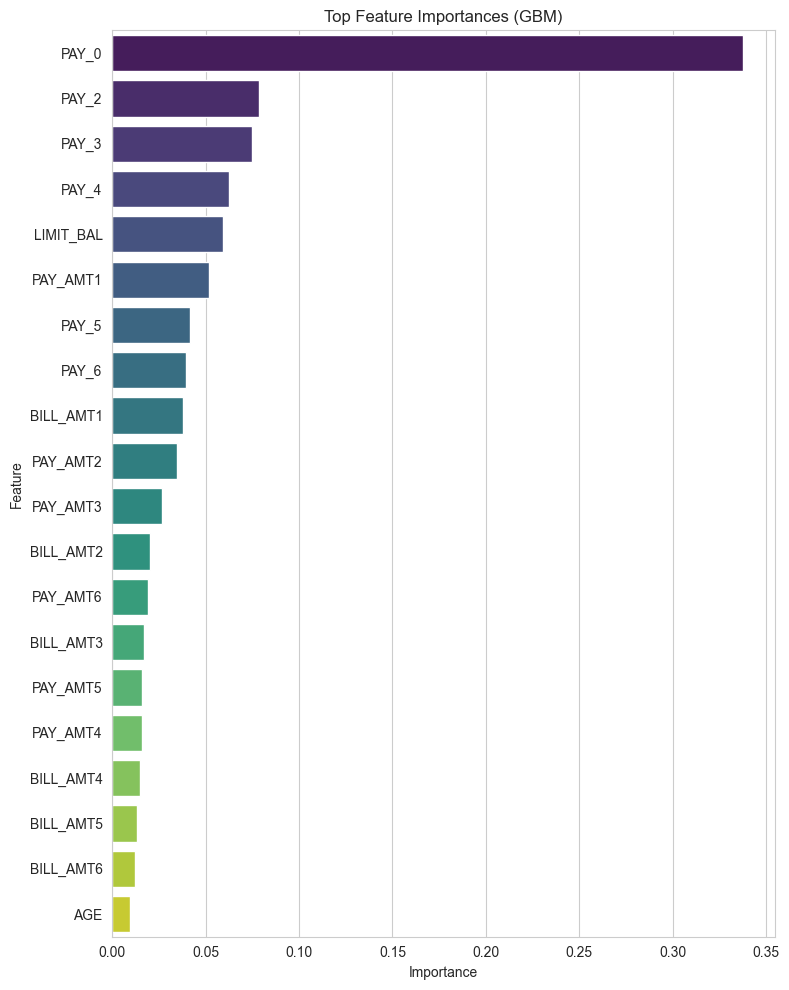

In [ ]:
# 13. Feature Importances
pre = final_model.named_steps["preprocess"]
feat_names: List[str] = []
feat_names += num_cols
if cat_cols:
    ohe = pre.named_transformers_["cat"].named_steps["onehot"]
    try:
        ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
    except Exception:
        ohe_names = ohe.get_feature_names(cat_cols).tolist()
    feat_names += ohe_names

model = final_model.named_steps["model"]
if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    idx = np.argsort(importances)[::-1][:CFG.top_n_features_plot]
    plt.figure(figsize=(8, max(4, CFG.top_n_features_plot//2)))
    sns.barplot(x=importances[idx], y=[feat_names[i] for i in idx], orient="h", palette="viridis")
    plt.title("Top Feature Importances (GBM)")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.outputs_dir, "feature_importances_top.png"), bbox_inches="tight")
    plt.show()
else:
    print("Model does not expose feature_importances_ (unexpected for GBM)")

In [ ]:
# 14. Cross-validated ROC-AUC on Train+Val (manual loop to pass sample_weight)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.base import clone

skf = StratifiedKFold(n_splits=CFG.n_splits_cv, shuffle=True, random_state=CFG.random_state)
cv_scores = []
for tr_idx, va_idx in skf.split(X_train_val, y_train_val):
    X_tr, X_va = X_train_val.iloc[tr_idx], X_train_val.iloc[va_idx]
    y_tr, y_va = y_train_val.iloc[tr_idx], y_train_val.iloc[va_idx]

    est = clone(final_model)
    est.fit(X_tr, y_tr, model__sample_weight=compute_balanced_sample_weights(y_tr))
    proba = est.predict_proba(X_va)[:, 1]
    cv_scores.append(roc_auc_score(y_va, proba))

cv_scores = np.array(cv_scores)
print(f"CV ROC-AUC (Train+Val): mean={cv_scores.mean():.4f}, std={cv_scores.std():.4f}")

CV ROC-AUC (Train+Val): mean=0.7843, std=0.0065


In [ ]:
# 15. Save Artifacts (model, report, CV results)

def _json_default(o):
    import numpy as _np
    if isinstance(o, (_np.integer,)):
        return int(o)
    if isinstance(o, (_np.floating,)):
        return float(o)
    if isinstance(o, (_np.ndarray,)):
        return o.tolist()
    return str(o)

artifacts = {
    "best_params": search.best_params_,
    "cv_best_score": float(search.best_score_),
    "validation_metrics": {k: float(v) for k, v in val_metrics.items()},
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
    "cv_roc_auc_mean_train_val": float(cv_scores.mean()),
    "cv_roc_auc_std_train_val": float(cv_scores.std()),
    "target_column": target_col,
    "numeric_cols": list(map(str, num_cols)),
    "categorical_cols": list(map(str, cat_cols)),
}

with open(os.path.join(CFG.outputs_dir, "evaluation_report.json"), "w", encoding="utf-8") as f:
    json.dump(artifacts, f, indent=2, ensure_ascii=False, default=_json_default)

cv_df = pd.DataFrame(search.cv_results_)
cv_df.to_csv(os.path.join(CFG.outputs_dir, "random_search_results.csv"), index=False)

model_path = os.path.join(CFG.models_dir, "gbm_credit_default.joblib")
joblib.dump(final_model, model_path)

print("Model saved:", model_path)
print("Outputs (first 10):", sorted(os.listdir(CFG.outputs_dir))[:10])

Model saved: ./models\gbm_credit_default.joblib
Outputs (first 10): ['actual_vs_predicted_calibration.png', 'actual_vs_predicted_line.png', 'actual_vs_predicted_visual.png', 'calibration_curve.png', 'class_distribution.png', 'confusion_matrix.png', 'corr_heatmap.png', 'cumulative_gains.png', 'evaluation_report.json', 'feature_importances_top.png']
